In [310]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib 

In [311]:
# Load the dataset of Walmart sales
Data_raw = pd.read_csv('/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/data/raw/Walmart_Sales.csv')
Data_raw.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [312]:
# Load the dataset of competitor prices
Data_compi = pd.read_csv('/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/data/external/competitor_prices.csv')
Data_compi.head()

,Product_Name,Current_Price,Rating,Timestamp
0,bb Royal\nSona Masoori Rice/Akki Raw Rice/Akki...,₹599.00,Shop by,2026-04-27 13:38:56.661806
1,Sona Masoori Rice/Akki Raw Rice/Akki - Super P...,₹1000.00,Category,2026-04-27 13:38:56.661806
2,Daawat\nRozana Super Basmati Rice\n3.8\n17868 ...,₹70.50,Select Location,2026-04-27 13:38:56.661806
3,Rozana Super Basmati Rice,₹100.00,Select Location,2026-04-27 13:38:56.661806
4,bb Popular\nSona Masoori New Pongal Rice\n5 kg,₹331.00,Select Location,2026-04-27 13:38:56.661806


## Feature Enginnering

In [313]:
# 1. Convert the 'Date' column to Datetime objects
# The Walmart dataset usually uses DD-MM-YYYY format, so we specify the format accordingly

Data_raw['Date'] = pd.to_datetime(Data_raw['Date'], dayfirst=True)

# 2. Extract basic 'Date' components: Day, Month, Year
Data_raw['Day'] = Data_raw['Date'].dt.day
Data_raw['Month'] = Data_raw['Date'].dt.month
Data_raw['Year'] = Data_raw['Date'].dt.year

# 3. Extract calender-spedific features
Data_raw['week_of_year'] = Data_raw['Date'].dt.isocalendar().week
Data_raw['day_of_week'] = Data_raw['Date'].dt.dayofweek
Data_raw['quarter'] = Data_raw['Date'].dt.quarter

# 4. create the 'is_weekend' flag (1 for Saturday and Sunday, 0 for weekdays)
Data_raw['is_weekend'] = Data_raw['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Create the 'season' feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
Data_raw['season'] = Data_raw['Month'].apply(get_season)

# Display the results
print(Data_raw[['Date', 'Day', 'Month', 'Year', 'week_of_year', 'day_of_week', 'quarter', 'is_weekend', 'season']].head())



        Date  Day  Month  Year  week_of_year  day_of_week  quarter  \
0 2010-02-05    5      2  2010             5            4        1   
1 2010-02-12   12      2  2010             6            4        1   
2 2010-02-19   19      2  2010             7            4        1   
3 2010-02-26   26      2  2010             8            4        1   
4 2010-03-05    5      3  2010             9            4        1   

   is_weekend  season  
0           0  Winter  
1           0  Winter  
2           0  Winter  
3           0  Winter  
4           0  Spring  


In [314]:
# Lag Features
# Create lag features for the 'Weekly_Sales' column
Data_raw['sales_lag_1'] = (Data_raw.groupby('Store')['Weekly_Sales'].shift(1)) # Lag of 1 week
Data_raw['sales_lag_2'] = (Data_raw.groupby('Store')['Weekly_Sales'].shift(2)) # Lag of 2 weeks
Data_raw['sales_lag_4'] = (Data_raw.groupby('Store')['Weekly_Sales'].shift(4)) # Lag of 4 weeks (1 month)
Data_raw['sales_lag_8'] = (Data_raw.groupby('Store')['Weekly_Sales'].shift(8)) # Lag of 8 weeks (2 months)

# Data_raw['sales_lag_5'] = (Data_raw.groupby('Store')['Weekly_Sales'].shift(52)) # Lag of 52 weeks (1 year)

# Data_raw.dropna(inplace=True) # Drop rows with NaN values resulting from lag features
Data_raw.isnull().sum() # Check for NaN values in the lag features

display_col = ['Store', 'Date', 'Weekly_Sales', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_lag_8']
print(Data_raw[display_col].head(10))


   Store       Date  Weekly_Sales  sales_lag_1  sales_lag_2  sales_lag_4  \
0      1 2010-02-05    1643690.90          NaN          NaN          NaN   
1      1 2010-02-12    1641957.44   1643690.90          NaN          NaN   
2      1 2010-02-19    1611968.17   1641957.44   1643690.90          NaN   
3      1 2010-02-26    1409727.59   1611968.17   1641957.44          NaN   
4      1 2010-03-05    1554806.68   1409727.59   1611968.17   1643690.90   
5      1 2010-03-12    1439541.59   1554806.68   1409727.59   1641957.44   
6      1 2010-03-19    1472515.79   1439541.59   1554806.68   1611968.17   
7      1 2010-03-26    1404429.92   1472515.79   1439541.59   1409727.59   
8      1 2010-04-02    1594968.28   1404429.92   1472515.79   1554806.68   
9      1 2010-04-09    1545418.53   1594968.28   1404429.92   1439541.59   

   sales_lag_8  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  
5          NaN  
6          NaN  
7          NaN  
8   164369

In [315]:
# 1. Calculate the 4-week and 8-week Rolling Mean of Sales
Data_raw['sales_rolling_mean_4'] = Data_raw.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(window=4).mean()
)

Data_raw['sales_rolling_mean_8'] = Data_raw.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(window=8).mean()
)

# 2. Calculate the 4-week and 8-week Rolling Standard Deviation (Volatility)
Data_raw['sales_rolling_std_4'] = Data_raw.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(window=4).std()
)

Data_raw['sales_rolling_std_8'] = Data_raw.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(window=8).std()
)

# 3. Always check for new NaNs created at the start of the window
print(Data_raw[['Store', 'Date', 'Weekly_Sales', 'sales_rolling_mean_4', 'sales_rolling_std_4', 'sales_rolling_mean_8', 'sales_rolling_std_8']].head(10))

   Store       Date  Weekly_Sales  sales_rolling_mean_4  sales_rolling_std_4  \
0      1 2010-02-05    1643690.90                   NaN                  NaN   
1      1 2010-02-12    1641957.44                   NaN                  NaN   
2      1 2010-02-19    1611968.17                   NaN                  NaN   
3      1 2010-02-26    1409727.59                   NaN                  NaN   
4      1 2010-03-05    1554806.68          1.576836e+06        112353.415114   
5      1 2010-03-12    1439541.59          1.554615e+06        103135.002548   
6      1 2010-03-19    1472515.79          1.504011e+06         95360.050839   
7      1 2010-03-26    1404429.92          1.469148e+06         62599.457150   
8      1 2010-04-02    1594968.28          1.467823e+06         64308.381016   
9      1 2010-04-09    1545418.53          1.477864e+06         82871.762296   

   sales_rolling_mean_8  sales_rolling_std_8  
0                   NaN                  NaN  
1                   NaN  

In [316]:
# Clean up NaNs created by the Velocity calculation
Data_raw.dropna(inplace=True)

In [317]:
# Set a seed so your results are reproducible (important for ML)
np.random.seed(42)

# 1. Define Stock Velocity (How fast items move)
# We use the rolling mean we just created as the 'speed' of sales
Data_raw['Stock_Velocity'] = Data_raw['sales_rolling_mean_4']

# 2. Simulate Current Stock
# We assume the store keeps between 10 to 30 days of stock on hand
# Formula: Current_Stock = Stock_Velocity * (Random Days Buffer)
Data_raw['Current_Stock'] = Data_raw['Stock_Velocity'] * np.random.randint(10, 30, size=len(Data_raw))
Data_raw['Current_Stock'] = Data_raw['Current_Stock'].astype(int)

# 3. Calculate Weeks Until Stockout
# This is our key metric: How many weeks until the shelf is empty?
Data_raw['Weeks_Until_Stockout'] = Data_raw['Current_Stock'] / Data_raw['Stock_Velocity']
Data_raw['Weeks_Until_Stockout'] = Data_raw['Weeks_Until_Stockout'].round(2)

# 4. Create the Reorder Flag (Actionable Insight)
# If we have less than 20 weeks of stock left, we need to reorder (1), otherwise (0)
Data_raw['Reorder_Flag'] = (Data_raw['Weeks_Until_Stockout'] < 20).astype(int)

# Display the inventory dashboard
display_cols = ['Store', 'Date', 'Weekly_Sales', 'Current_Stock', 'Weeks_Until_Stockout', 'Reorder_Flag']
print(Data_raw[display_cols].head(10))

# Checking the distribution of the Reorder Flag for "Class Imbalance"
print(Data_raw['Reorder_Flag'].value_counts(normalize=True) * 100)


    Store       Date  Weekly_Sales  Current_Stock  Weeks_Until_Stockout  \
8       1 2010-04-02    1594968.28       23485175                  16.0   
9       1 2010-04-09    1545418.53       42858052                  29.0   
10      1 2010-04-16    1466058.28       36103995                  24.0   
11      1 2010-04-23    1391256.12       30054375                  20.0   
12      1 2010-04-30    1425100.71       25490230                  17.0   
13      1 2010-05-07    1603955.12       23311334                  16.0   
14      1 2010-05-14    1494251.50       41204591                  28.0   
15      1 2010-05-21    1399662.07       29572817                  20.0   
16      1 2010-05-28    1432069.95       29614847                  20.0   
17      1 2010-06-04    1615524.71       19272300                  13.0   

    Reorder_Flag  
8              1  
9              0  
10             0  
11             0  
12             1  
13             1  
14             0  
15             0  
16 

## Compititor Price Feature Engineering
Here the compititor is **BigBasket**

In [318]:
competitor_df = pd.read_csv('/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/data/external/competitor_prices.csv')
print(competitor_df.head(2))

                                        Product_Name Current_Price    Rating  \
0  bb Royal\nSona Masoori Rice/Akki Raw Rice/Akki...       ₹599.00   Shop by   
1  Sona Masoori Rice/Akki Raw Rice/Akki - Super P...      ₹1000.00  Category   

                    Timestamp  
0  2026-04-27 13:38:56.661806  
1  2026-04-27 13:38:56.661806  


In [319]:
# Force the column to be string first (in case there are mixed types)
competitor_df['Current_Price'] = competitor_df['Current_Price'].astype(str)

# Use a Regex that keeps only digits 0-9 and decimal points (.)
# Everything else (letters, symbols, emojis) get deleted
competitor_df['Current_Price'] = (competitor_df['Current_Price'].str.replace(r'[^0-9.]', '', regex=True).astype(float))

# Now we can filter out any prices that are outside a reasonable range (e.g., less than $50 or greater than $200)
competitor_df = competitor_df[
    (competitor_df['Current_Price'] > 50) &
    (competitor_df['Current_Price'] < 200)
]

# Calculate the average competitor price
avg_comp_price = competitor_df['Current_Price'].mean()

# Convert to numeric, and use errors='coerce'
# This turns any remaining 'garbage' text into 'NaN' instead of crashing the code
competitor_df['Current_Price'] = pd.to_numeric(competitor_df['Current_Price'], errors='coerce')

# Drop any rows where the price ended up being empty/NaN
competitor_df.dropna(subset=['Current_Price'], inplace=True)

# Check your work
print("Cleaned Data Types:")
print(competitor_df.dtypes)
print("\nFirst 5 Cleaned Prices:")
print(competitor_df['Current_Price'].head())

Cleaned Data Types:
Product_Name         str
Current_Price    float64
Rating               str
Timestamp            str
dtype: object

First 5 Cleaned Prices:
2      70.5
3     100.0
10    106.5
11    122.0
23     69.0
Name: Current_Price, dtype: float64


In [320]:
# category Merge
competitor_df['Category'] = 'Rice'

# Creating a Internal Price Proxy
Data_raw['Our_Price'] = np.random.randint(70, 120, size=len(Data_raw))

# Merge Competitor pricing
avg_comp_price = competitor_df['Current_Price'].mean()
np.random.seed(42)

Data_raw['Competitor_Price'] = np.random.choice(
    competitor_df['Current_Price'],
    size=len(Data_raw)
)

# Price gap
Data_raw['Price_Gap'] = (Data_raw['Our_Price']- Data_raw['Competitor_Price'])

# Relative Price Index
Data_raw['Relative_Price_Index'] = (Data_raw['Our_Price']/ Data_raw['Competitor_Price']).round(2)
Data_raw['Relative_Price_Index'] = (Data_raw['Relative_Price_Index'].clip(0.5, 1.5))
print(Data_raw[['Our_Price','Competitor_Price','Price_Gap','Relative_Price_Index']].head(10))
print(competitor_df['Current_Price'].describe())

    Our_Price  Competitor_Price  Price_Gap  Relative_Price_Index
8          85             61.00      24.00                  1.39
9          85             94.00      -9.00                  0.90
10         77            119.60     -42.60                  0.64
11         98             80.04      17.96                  1.22
12        108             59.84      48.16                  1.50
13         97             80.00      17.00                  1.21
14         75            119.60     -44.60                  0.63
15         85             72.45      12.55                  1.17
16         89             61.00      28.00                  1.46
17         85            110.00     -25.00                  0.77
count     29.000000
mean      93.610000
std       29.649341
min       58.000000
25%       72.450000
50%       89.000000
75%      110.000000
max      179.000000
Name: Current_Price, dtype: float64


## Target Engineering - "Optimal Price"
--> We have features but no real **learning objective for pricing**

### Core IDEA!
--> We wan the model to learn: ***"What price maximize revenue?"***

In [321]:
# Simulate price Elasticity
Data_raw['Elasticity'] = np.random.uniform(-2, -0.5, size=len(Data_raw))

# Create Adjust_sales based on price
Data_raw['Adjusted_Sales'] = (Data_raw['Weekly_Sales'] * (Data_raw['Our_Price'] / Data_raw['Competitor_Price']) ** Data_raw['Elasticity'])
# Clip it
Data_raw['Adjusted_Sales'] = Data_raw['Adjusted_Sales'].clip(lower=0.5 * Data_raw['Weekly_Sales'],upper=1.5 * Data_raw['Weekly_Sales'])
Data_raw['Adjusted_Sales'] = Data_raw['Adjusted_Sales'].round(0)

# Compute revenue
Data_raw['Revenue'] = Data_raw['Our_Price'] * Data_raw['Adjusted_Sales']
Data_raw['Revenue'] = Data_raw['Revenue'].round(0)

# Define Optimal_Price_Target
Data_raw['Optimal_Price_Target'] = (0.5 * Data_raw['Competitor_Price'] +0.5 * Data_raw['Our_Price'])
Data_raw['Optimal_Price_Target'] = Data_raw['Optimal_Price_Target'].round(2)

print(Data_raw[['Our_Price', 'Competitor_Price', 'Elasticity', 'Adjusted_Sales', 'Revenue', 'Optimal_Price_Target']].head(10))

check = Data_raw['Adjusted_Sales'] / Data_raw['Weekly_Sales']
print(check.describe())

    Our_Price  Competitor_Price  Elasticity  Adjusted_Sales      Revenue  \
8          85             61.00   -1.051413       1125265.0   95647525.0   
9          85             94.00   -1.765285       1845886.0  156900310.0   
10         77            119.60   -1.289118       2199087.0  169329699.0   
11         98             80.04   -0.925404       1153577.0  113050546.0   
12        108             59.84   -1.593586        712550.0   76955400.0   
13         97             80.00   -1.696619       1156688.0  112198736.0   
14         75            119.60   -1.529260       2241377.0  168103275.0   
15         85             72.45   -1.637749       1077445.0   91582825.0   
16         89             61.00   -1.677631        759857.0   67627273.0   
17         85            110.00   -1.362724       2295635.0  195128975.0   

    Optimal_Price_Target  
8                  73.00  
9                  89.50  
10                 98.30  
11                 89.02  
12                 83.92  
1

# MODELING

## Define Features and Target

In [322]:
features = [
    'Our_Price',
    'Competitor_Price',
    'Price_Gap',
    'Relative_Price_Index',
    'Elasticity',
    'Weekly_Sales',
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_4',
    'sales_rolling_mean_4',
    'sales_rolling_std_4',
    'Weeks_Until_Stockout',
    'Reorder_Flag'
]

target = 'Optimal_Price_Target'

## Train/Test Split

In [323]:
from sklearn.model_selection import train_test_split

X = Data_raw[features]
y = Data_raw[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Champion Model --> {Random Forest}

In [324]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [325]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Random Forest MAE:", mae)
print("Random Forest RMSE:", rmse)

Random Forest MAE: 0.10728378600822729
Random Forest RMSE: 0.17172403969945313


## Challanger Model --> {XGBoost}

In [326]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

## Compare Both The Models

In [327]:
mae_xgb = mean_absolute_error(y_test, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.09858352146227178
XGBoost RMSE: 0.13626359058737075


## Feature_Importance for Random Forest

In [328]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_importance.head(10))

Competitor_Price        0.796767
Our_Price               0.192649
Price_Gap               0.005917
Relative_Price_Index    0.004543
sales_rolling_std_4     0.000024
Elasticity              0.000023
Weeks_Until_Stockout    0.000020
sales_lag_2             0.000012
sales_lag_4             0.000012
Weekly_Sales            0.000011
dtype: float64


## Feature_Importance for XGBoost

In [329]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(10))

Competitor_Price        0.854366
Our_Price               0.145332
Relative_Price_Index    0.000089
Price_Gap               0.000085
sales_rolling_mean_4    0.000027
sales_lag_2             0.000018
sales_rolling_std_4     0.000017
sales_lag_1             0.000015
sales_lag_4             0.000015
Weekly_Sales            0.000015
dtype: float32


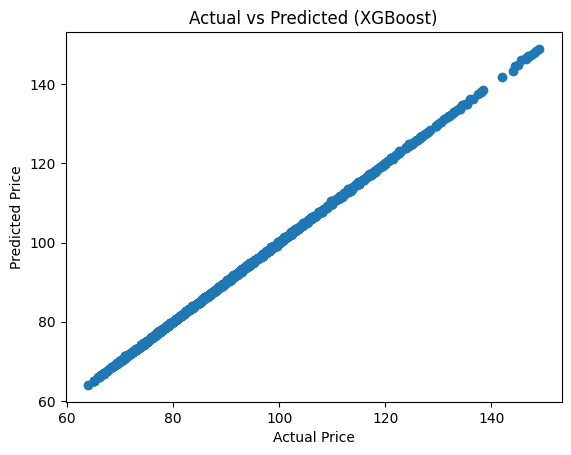

In [330]:
import matplotlib.pyplot as plt

plt.scatter(y_test, xgb_preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

## Save the Model

In [331]:
# Save trained XGBoost model
joblib.dump(xgb, "/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/model/xgb_model.pkl")

['/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/model/xgb_model.pkl']

In [332]:
# Save feature column order
joblib.dump(X.columns.tolist(), "/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/model/features.pkl")

['/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/model/features.pkl']

In [333]:
model = joblib.load('/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/model/xgb_model.pkl')
features = joblib.load('/Users/saikatgayen/WORKSPACE/Dynamic Pricing and Inventory Forcasting System/model/features.pkl')

print(type(model))
print(features)

<class 'xgboost.sklearn.XGBRegressor'>
['Our_Price', 'Competitor_Price', 'Price_Gap', 'Relative_Price_Index', 'Elasticity', 'Weekly_Sales', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4', 'sales_rolling_mean_4', 'sales_rolling_std_4', 'Weeks_Until_Stockout', 'Reorder_Flag']
